# COVID-19 Exploratory Data Analysis (EDA)

## Project Overview
This project analyzes COVID-19 patient data using Python and visualization techniques.

The analysis includes:
- COVID positive analysis
- Age distribution
- Gender analysis
- ICU analysis
- Mortality analysis
- Correlation heatmaps

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graph Styling
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [8]:
df = pd.read_csv(r'C:\Users\sp759\OneDrive\Desktop\COVID19-EDA-Project\Data\Covid Data.csv')

In [9]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [10]:
df.columns

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='str')

In [11]:
df.shape

(1048575, 21)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   USMER                 1048575 non-null  int64
 1   MEDICAL_UNIT          1048575 non-null  int64
 2   SEX                   1048575 non-null  int64
 3   PATIENT_TYPE          1048575 non-null  int64
 4   DATE_DIED             1048575 non-null  str  
 5   INTUBED               1048575 non-null  int64
 6   PNEUMONIA             1048575 non-null  int64
 7   AGE                   1048575 non-null  int64
 8   PREGNANT              1048575 non-null  int64
 9   DIABETES              1048575 non-null  int64
 10  COPD                  1048575 non-null  int64
 11  ASTHMA                1048575 non-null  int64
 12  INMSUPR               1048575 non-null  int64
 13  HIPERTENSION          1048575 non-null  int64
 14  OTHER_DISEASE         1048575 non-null  int64
 15  CARDIOVASCULAR        1048

In [13]:
df.isnull().sum()

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

In [14]:
df.columns = df.columns.str.strip()

In [15]:
df.columns

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='str')

In [16]:
df['COVID_POSITIVE'] = df['CLASIFFICATION_FINAL'].apply(
    lambda x: 1 if x <= 3 else 0
)

In [17]:
df['COVID_POSITIVE'].value_counts()

COVID_POSITIVE
0    656596
1    391979
Name: count, dtype: int64

# COVID Positive Analysis

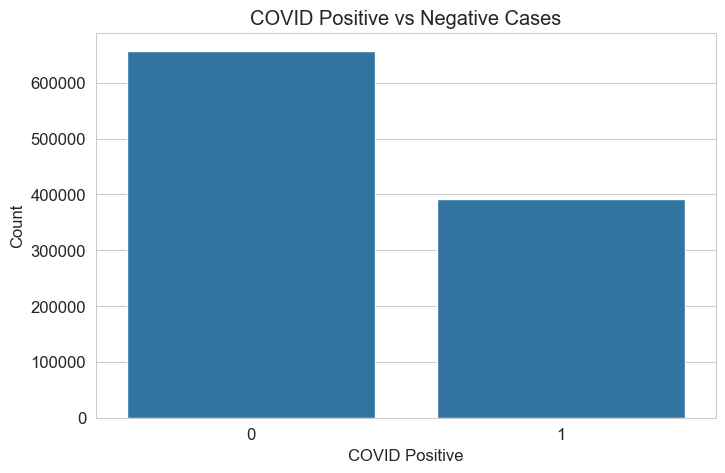

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x='COVID_POSITIVE', data=df)

plt.title('COVID Positive vs Negative Cases')
plt.xlabel('COVID Positive')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\3819709729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


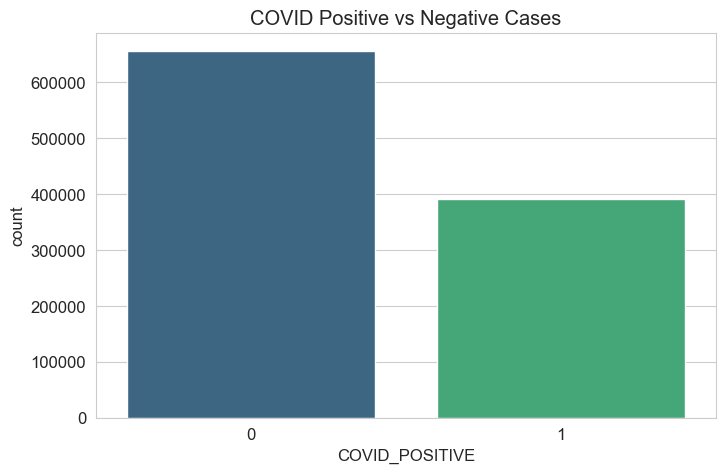

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='COVID_POSITIVE',
    data=df,
    palette='viridis'
)

plt.title('COVID Positive vs Negative Cases')

plt.savefig('../Images/covid_positive_cases.png')

plt.show()

# Insight

The dataset contains both COVID positive and negative patients.
COVID positive cases form a significant portion of the dataset.
This visualization helps understand overall infection distribution.

# Age Analysis

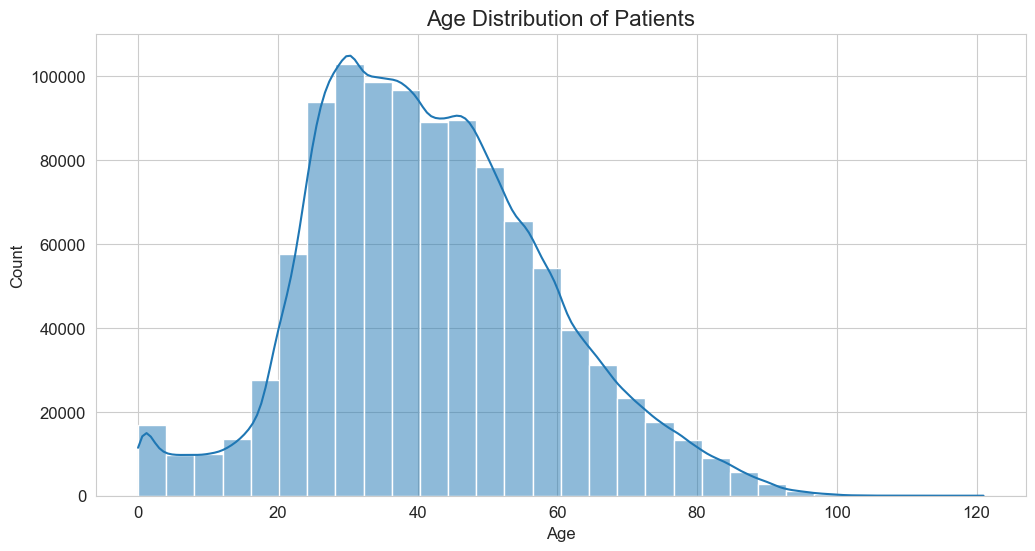

In [20]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['AGE'],
    bins=30,
    kde=True
)

plt.title('Age Distribution of Patients', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

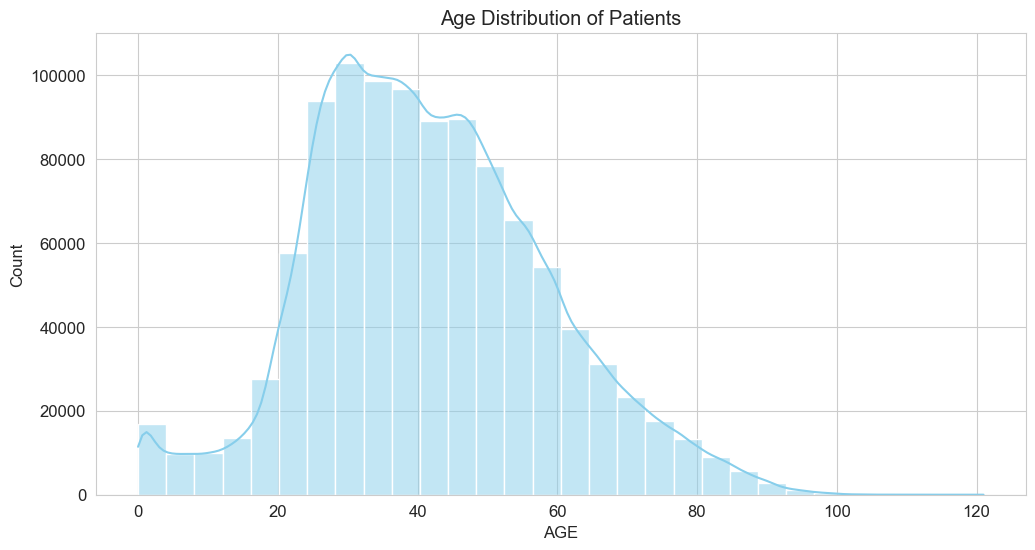

In [21]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['AGE'],
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title('Age Distribution of Patients')

plt.savefig('../Images/age_distribution.png')

plt.show()

# Age Distribution Insight

Most COVID patients belong to middle-age groups.
The dataset shows fewer cases among very young patients.
Age appears to be an important factor in COVID analysis.

# Gender Analysis

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\697375021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


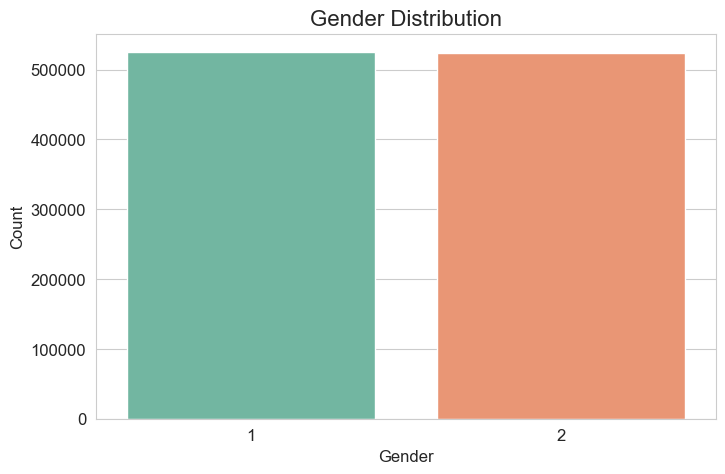

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='SEX',
    data=df,
    palette='Set2'
)

plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\3990940728.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


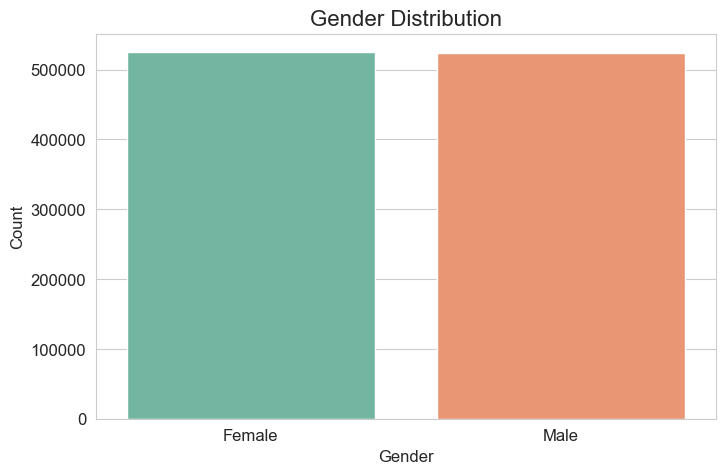

In [23]:
gender_labels = {
    1: 'Female',
    2: 'Male'
}

df['SEX_LABEL'] = df['SEX'].map(gender_labels)

plt.figure(figsize=(8,5))

sns.countplot(
    x='SEX_LABEL',
    data=df,
    palette='Set2'
)

plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\2116284462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


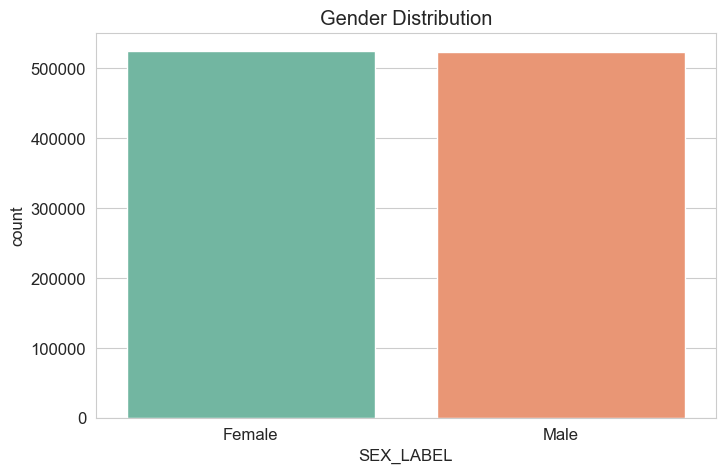

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='SEX_LABEL',
    data=df,
    palette='Set2'
)

plt.title('Gender Distribution')

plt.savefig('../Images/gender_distribution.png')

plt.show()

# Gender Insight

The dataset contains both male and female patients.
Gender-based analysis helps understand infection trends and health impacts across populations.

# Death Analysis

In [25]:
df['DIED'] = df['DATE_DIED'].apply(
    lambda x: 0 if x == '9999-99-99' else 1
)

In [26]:
df['DIED'].value_counts()

DIED
0    971633
1     76942
Name: count, dtype: int64

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\1663573443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


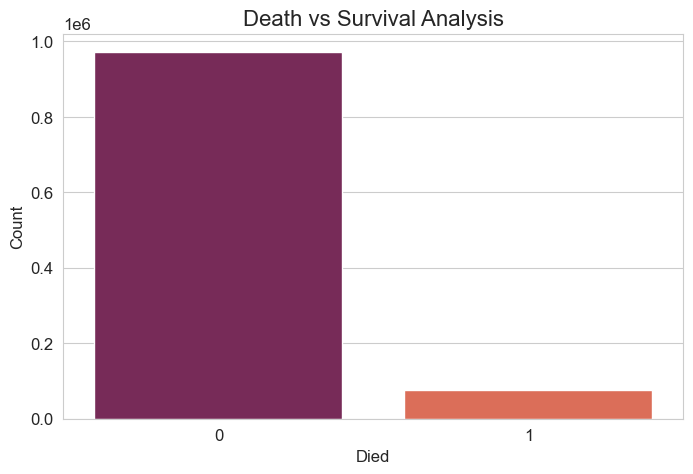

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIED',
    data=df,
    palette='rocket'
)

plt.title('Death vs Survival Analysis', fontsize=16)
plt.xlabel('Died')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\3501950775.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


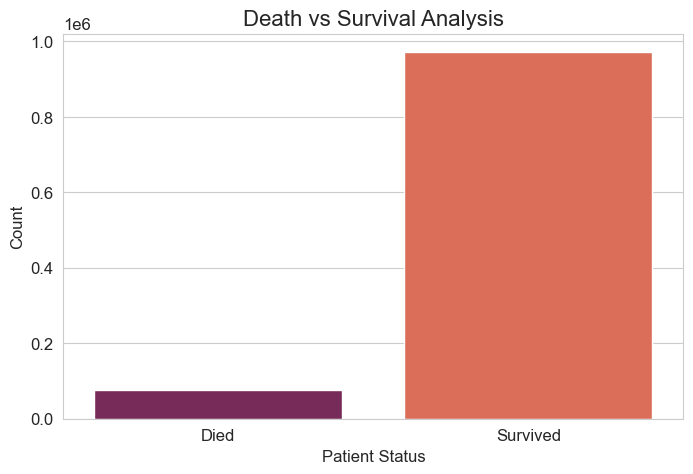

In [28]:
death_labels = {
    0: 'Survived',
    1: 'Died'
}

df['DIED_LABEL'] = df['DIED'].map(death_labels)

plt.figure(figsize=(8,5))

sns.countplot(
    x='DIED_LABEL',
    data=df,
    palette='rocket'
)

plt.title('Death vs Survival Analysis', fontsize=16)
plt.xlabel('Patient Status')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\388616320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


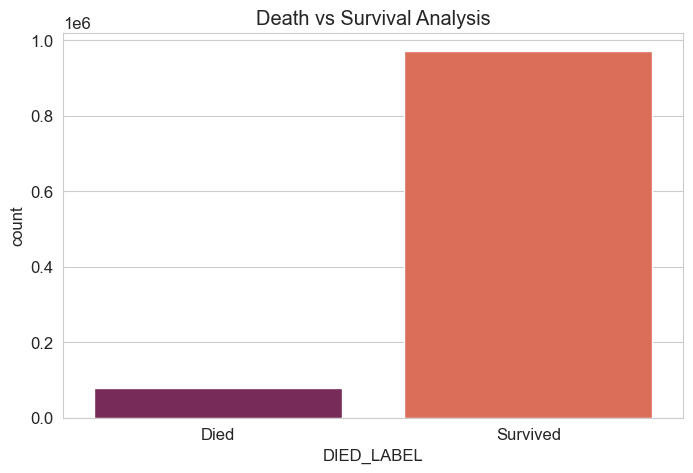

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIED_LABEL',
    data=df,
    palette='rocket'
)

plt.title('Death vs Survival Analysis')

plt.savefig('../Images/death_analysis.png')

plt.show()

# Death Analysis Insight

Most patients survived COVID-19, while a smaller portion resulted in death.
This analysis helps understand mortality trends in the dataset.


Boxplot

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\1845716601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


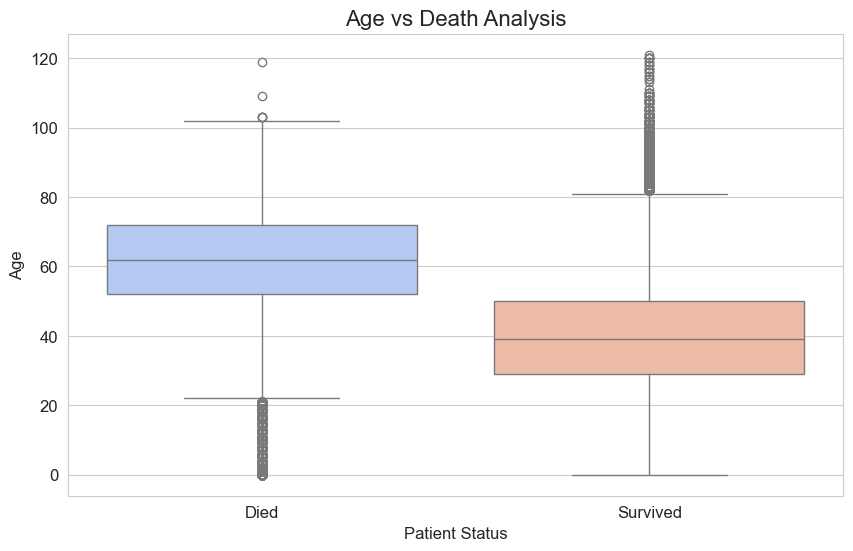

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='DIED_LABEL',
    y='AGE',
    data=df,
    palette='coolwarm'
)

plt.title('Age vs Death Analysis', fontsize=16)
plt.xlabel('Patient Status')
plt.ylabel('Age')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\2539693391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


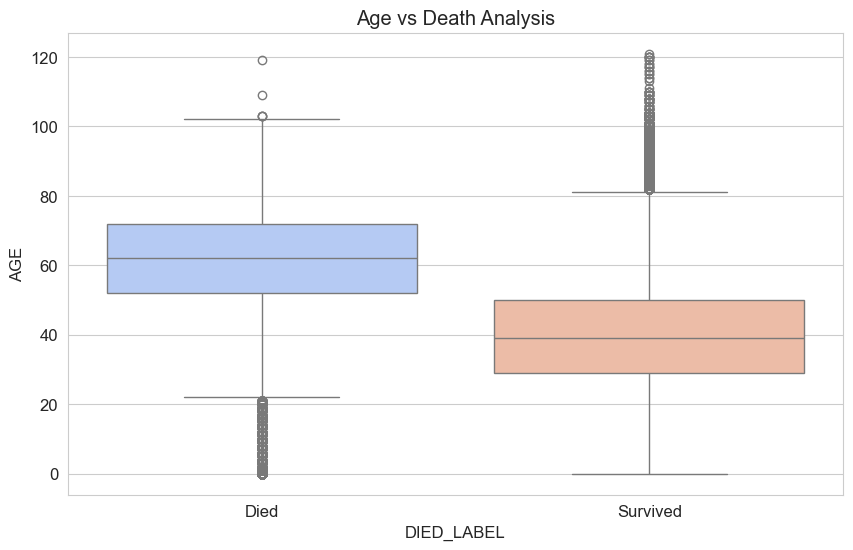

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='DIED_LABEL',
    y='AGE',
    data=df,
    palette='coolwarm'
)

plt.title('Age vs Death Analysis')

plt.savefig('../Images/age_vs_death.png')

plt.show()

# Age vs Death Insight

Older patients showed higher mortality trends compared to younger patients.
Age appears to be a significant factor affecting COVID-19 outcomes.

ICU Labels

In [32]:
icu_labels = {
    1: 'ICU',
    2: 'No ICU'
}

df['ICU_LABEL'] = df['ICU'].map(icu_labels)

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\1311956805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


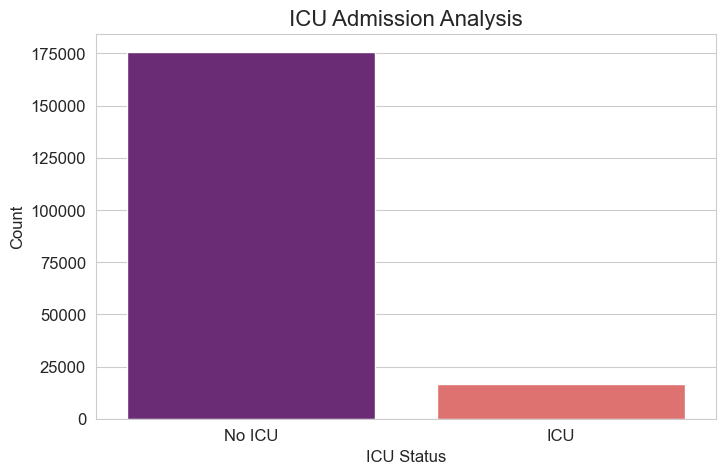

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='ICU_LABEL',
    data=df,
    palette='magma'
)

plt.title('ICU Admission Analysis', fontsize=16)
plt.xlabel('ICU Status')
plt.ylabel('Count')

plt.show()

# ICU Analysis Insight

Only a smaller percentage of patients required ICU admission.
ICU cases indicate severe COVID-19 conditions and critical patient status.

Diabetes Labels

In [34]:
diabetes_labels = {
    1: 'Diabetes',
    2: 'No Diabetes'
}

df['DIABETES_LABEL'] = df['DIABETES'].map(diabetes_labels)

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\3898971645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


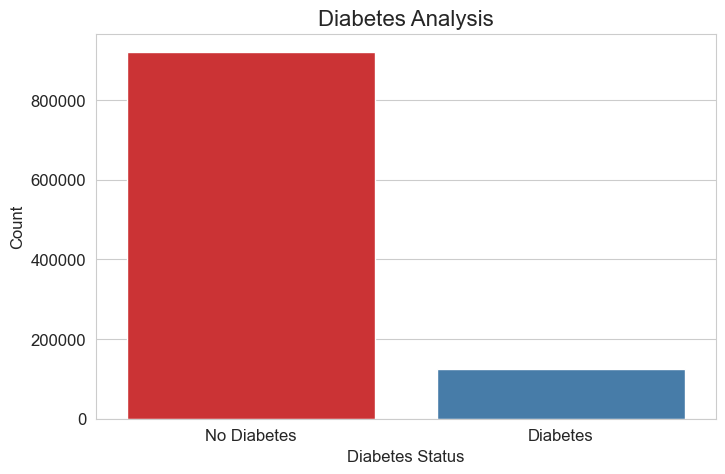

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIABETES_LABEL',
    data=df,
    palette='Set1'
)

plt.title('Diabetes Analysis', fontsize=16)
plt.xlabel('Diabetes Status')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\908968516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


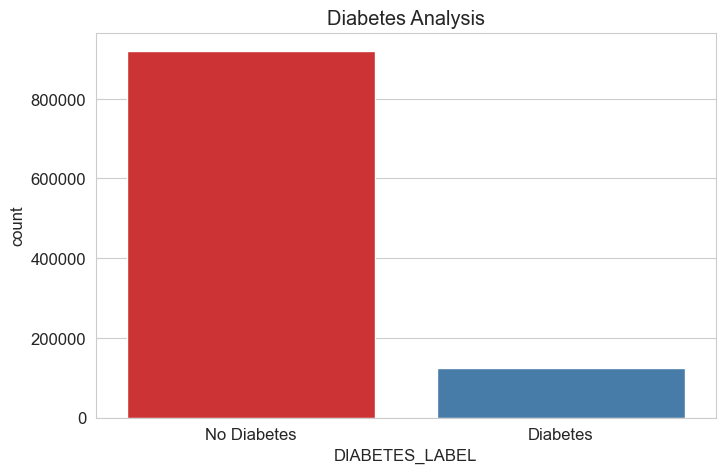

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIABETES_LABEL',
    data=df,
    palette='Set1'
)

plt.title('Diabetes Analysis')

plt.savefig('../Images/diabetes_analysis.png')

plt.show()

# Diabetes Insight

The dataset includes both diabetic and non-diabetic patients.
Diabetes is an important health factor associated with COVID-19 severity.

In [37]:
obesity_labels = {
    1: 'Obesity',
    2: 'No Obesity'
}

df['OBESITY_LABEL'] = df['OBESITY'].map(obesity_labels)

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\947678811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


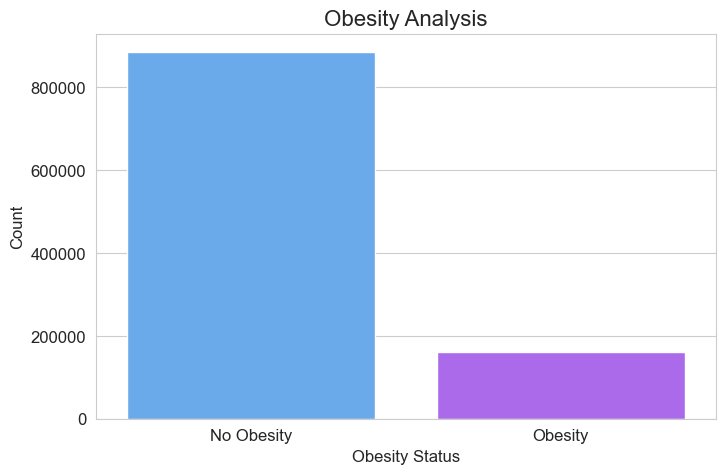

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OBESITY_LABEL',
    data=df,
    palette='cool'
)

plt.title('Obesity Analysis', fontsize=16)
plt.xlabel('Obesity Status')
plt.ylabel('Count')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\194130097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


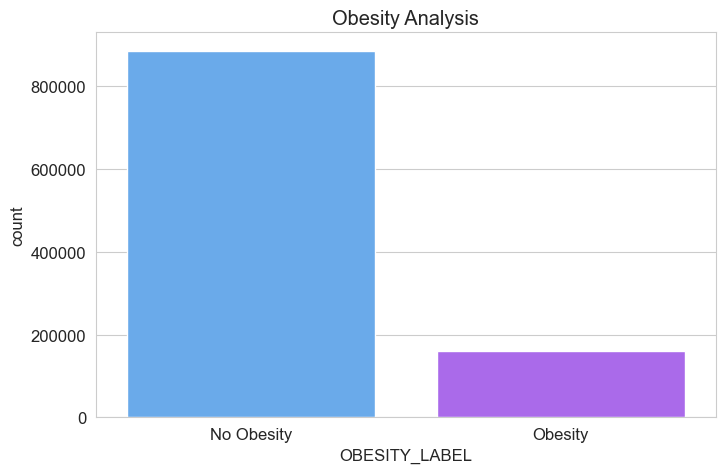

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OBESITY_LABEL',
    data=df,
    palette='cool'
)

plt.title('Obesity Analysis')

plt.savefig('../Images/obesity_analysis.png')

plt.show()

# Obesity Insight

Obesity appears as an important health condition among COVID-19 patients.
This factor may contribute to increased health complications.

In [40]:
numeric_df = df.select_dtypes(include='number')

In [41]:
numeric_df.columns

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'INTUBED', 'PNEUMONIA',
       'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU',
       'COVID_POSITIVE', 'DIED'],
      dtype='str')

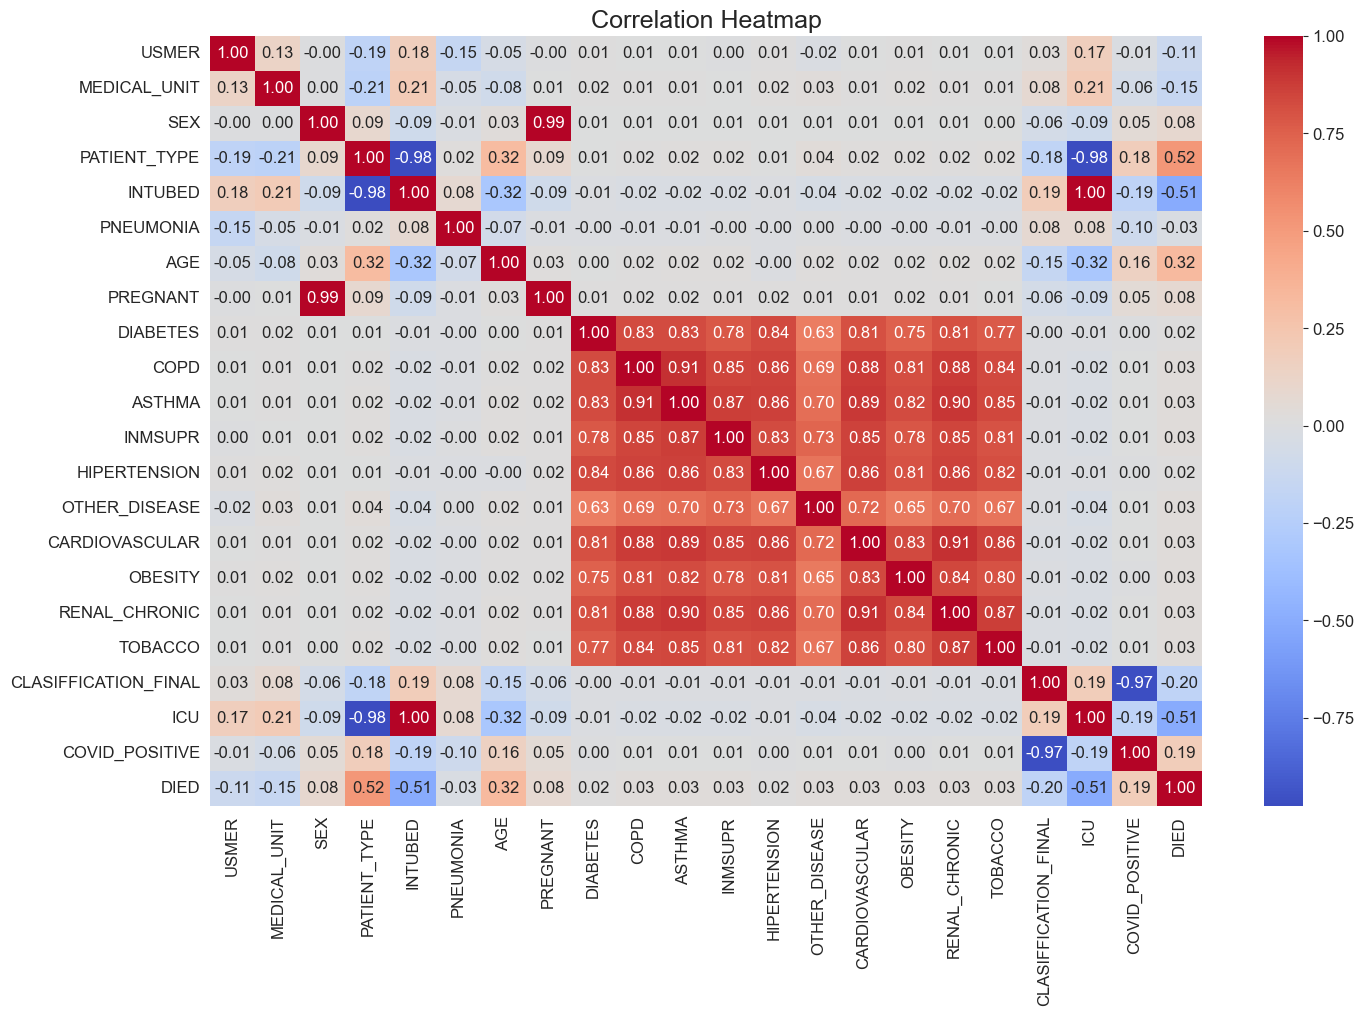

In [42]:
plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=18)

plt.show()

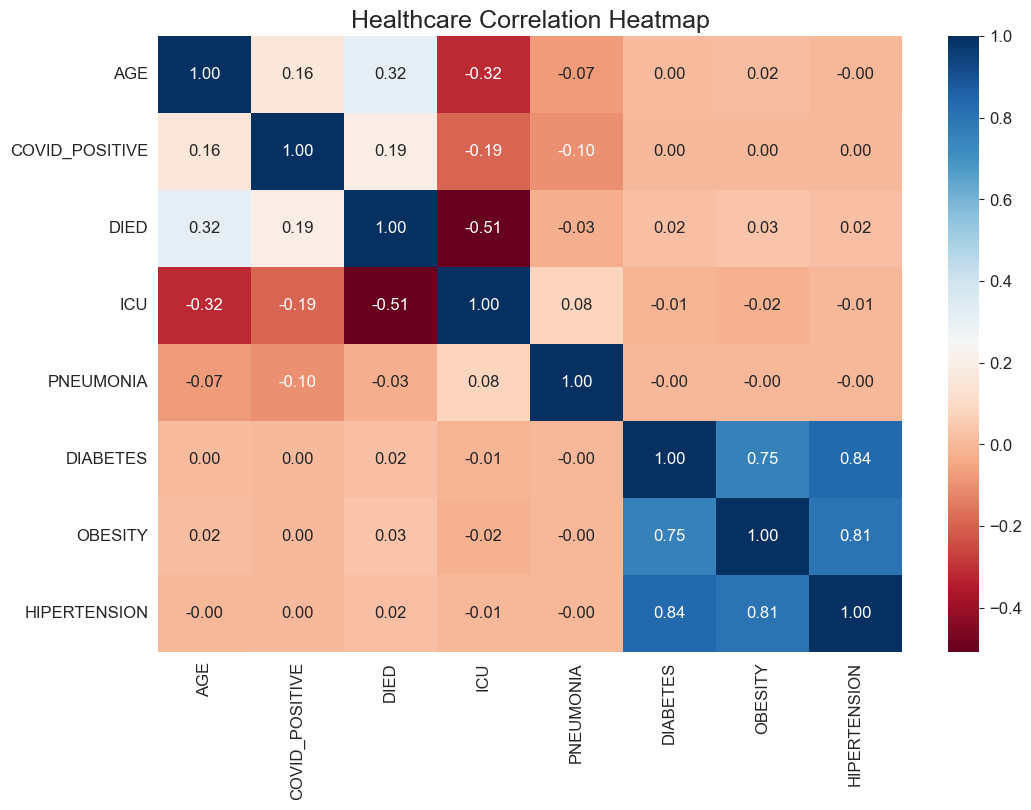

In [43]:
selected_columns = [
    'AGE',
    'COVID_POSITIVE',
    'DIED',
    'ICU',
    'PNEUMONIA',
    'DIABETES',
    'OBESITY',
    'HIPERTENSION'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap='RdBu',
    fmt='.2f'
)

plt.title('Healthcare Correlation Heatmap', fontsize=18)

plt.show()

# Correlation Heatmap Insight

The heatmap highlights relationships between important healthcare variables.
Age, ICU admission, pneumonia, and other medical conditions show correlations with patient outcomes.
Correlation analysis helps identify factors associated with severe COVID-19 cases.

AGE vs ICU

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\231938548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


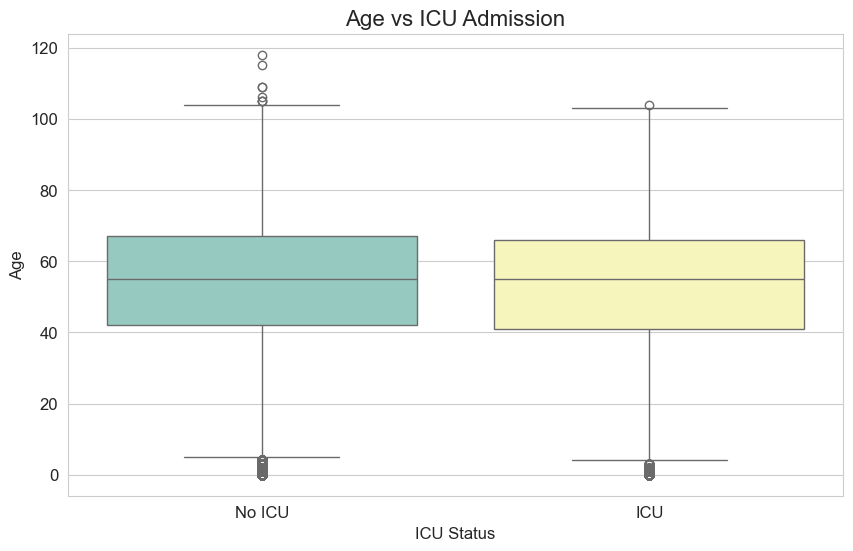

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='ICU_LABEL',
    y='AGE',
    data=df,
    palette='Set3'
)

plt.title('Age vs ICU Admission', fontsize=16)
plt.xlabel('ICU Status')
plt.ylabel('Age')

plt.show()

C:\Users\sp759\AppData\Local\Temp\ipykernel_13520\3328143587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


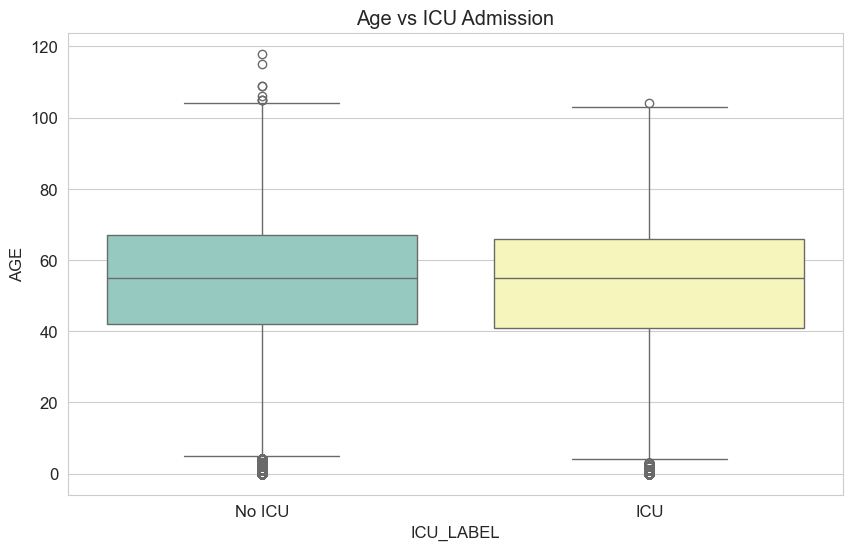

In [45]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='ICU_LABEL',
    y='AGE',
    data=df,
    palette='Set3'
)

plt.title('Age vs ICU Admission')

plt.savefig('../Images/age_vs_icu.png')

plt.show()

# Age vs ICU Insight

Older patients showed a higher tendency for ICU admission.
This suggests that age is strongly associated with severe COVID-19 conditions.

Cross Analysis 


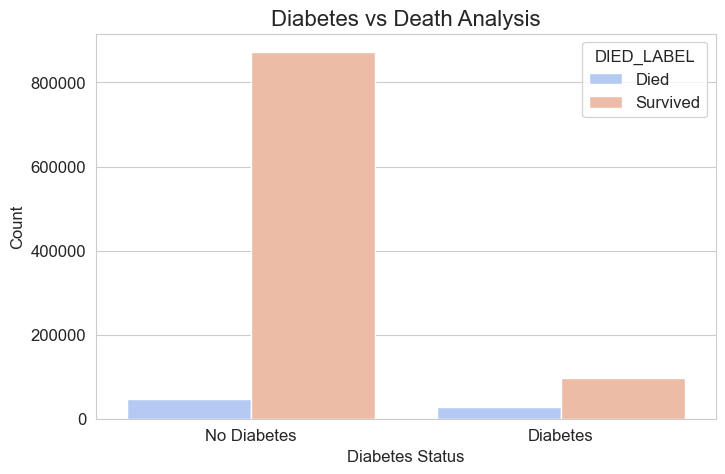

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIABETES_LABEL',
    hue='DIED_LABEL',
    data=df,
    palette='coolwarm'
)

plt.title('Diabetes vs Death Analysis', fontsize=16)
plt.xlabel('Diabetes Status')
plt.ylabel('Count')

plt.show()

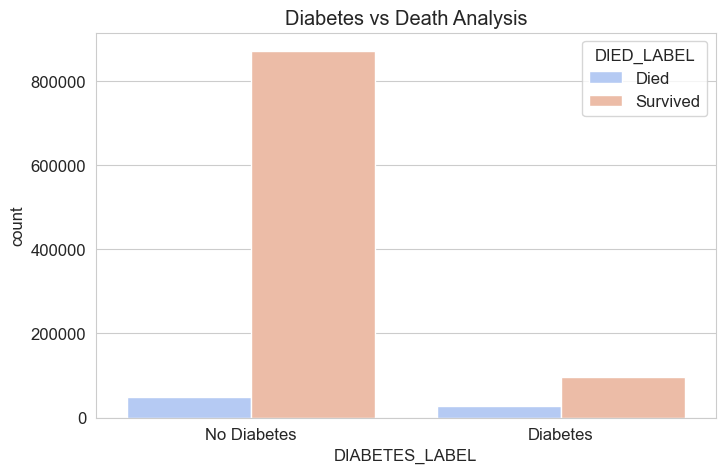

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='DIABETES_LABEL',
    hue='DIED_LABEL',
    data=df,
    palette='coolwarm'
)

plt.title('Diabetes vs Death Analysis')

plt.savefig('../Images/diabetes_vs_death.png')

plt.show()

# Diabetes vs Death Insight

Patients with diabetes showed notable mortality trends compared to non-diabetic patients.
Diabetes may contribute to severe COVID-19 outcomes.

In [48]:
pneumonia_labels = {
    1: 'Pneumonia',
    2: 'No Pneumonia'
}

df['PNEUMONIA_LABEL'] = df['PNEUMONIA'].map(pneumonia_labels)

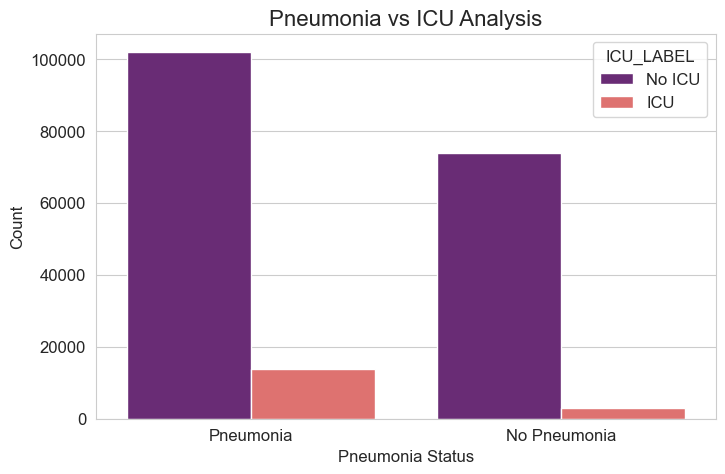

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='PNEUMONIA_LABEL',
    hue='ICU_LABEL',
    data=df,
    palette='magma'
)

plt.title('Pneumonia vs ICU Analysis', fontsize=16)
plt.xlabel('Pneumonia Status')
plt.ylabel('Count')

plt.show()

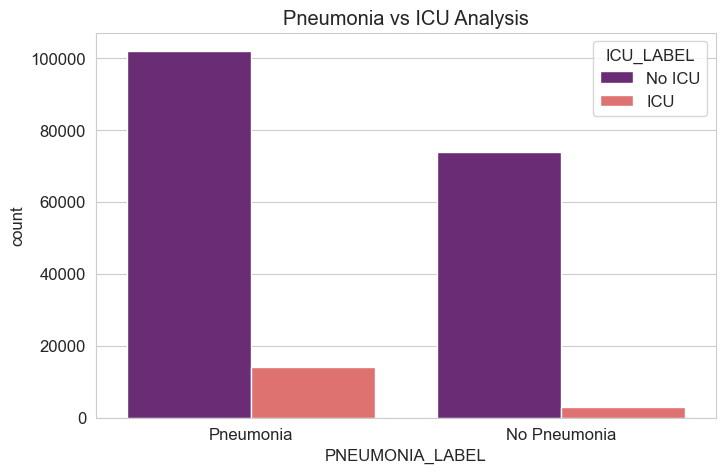

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='PNEUMONIA_LABEL',
    hue='ICU_LABEL',
    data=df,
    palette='magma'
)

plt.title('Pneumonia vs ICU Analysis')

plt.savefig('../Images/pneumonia_vs_icu.png')

plt.show()

# Pneumonia vs ICU Insight

Patients with pneumonia showed higher ICU admission patterns.
Pneumonia appears strongly associated with severe COVID-19 conditions.

# Final Conclusion

This project explored healthcare trends and COVID-19 patient characteristics using exploratory data analysis techniques.

Key findings:
- Older patients showed higher mortality and ICU trends
- Health conditions such as diabetes and pneumonia were associated with severe outcomes
- Correlation analysis revealed relationships between healthcare factors and patient severity

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [51]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sp759\OneDrive\Desktop\COVID19-EDA-Project\Data\Covid Data.csv')

In [52]:
df.columns = df.columns.str.strip()

In [53]:
df['COVID_POSITIVE'] = df['CLASIFFICATION_FINAL'].apply(
    lambda x: 1 if x <= 3 else 0
)

In [54]:
df['COVID_POSITIVE'] = df['CLASIFFICATION_FINAL'].apply(
    lambda x: 1 if x <= 3 else 0
)

In [55]:
df.to_csv('../Data/cleaned_covid_data.csv', index=False)